<a href="https://colab.research.google.com/github/ThaisEDomingues/atividade_45_3/blob/main/Atividade45_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
from scipy.stats import chi2

# Step 2: Load the dataset
df = pd.read_csv("product.csv")

# Step 3: Create a contingency table
contingency_table = pd.crosstab(df["Gender"], df["Preferred Product"])

# Step 4: Calculate row and column totals
row_totals = contingency_table.sum(axis=1)
col_totals = contingency_table.sum(axis=0)
grand_total = contingency_table.values.sum()

# Step 5: Compute expected frequencies manually
expected_frequencies = np.outer(row_totals, col_totals) / grand_total

# Step 6: Compute the Chi-Square statistic manually
chi_square_statistic = ((contingency_table - expected_frequencies) ** 2 / expected_frequencies).sum().sum()

# Step 7: Compute p-value manually
dof = (contingency_table.shape[0] - 1) * (contingency_table.shape[1] - 1)
p_value = 1 - chi2.cdf(chi_square_statistic, df=dof)

# Step 8: Display observed and expected frequencies
print("Observed Frequency Table:")
print(contingency_table)




Observed Frequency Table:
Preferred Product  Product A  Product B
Gender                                 
Female                     2          4
Male                       4          2


In [2]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Step 2: Load the dataset
df = pd.read_csv("product.csv")  # Ensure the CSV file is in the correct directory

# Step 3: Create a contingency table
contingency_table = pd.crosstab(df["Gender"], df["Preferred Product"])

# Step 4: Perform the Chi-Square Test automatically (without Yates' correction)
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table, correction=False)

# Step 5: Display observed and expected frequencies
print("Observed Frequency Table:")
print(contingency_table)

print("\nExpected Frequencies (Calculated Automatically):")
expected_df = pd.DataFrame(expected, columns=contingency_table.columns, index=contingency_table.index)
print(expected_df)

# Step 6: Display test statistics
print("\nChi-square Statistic:", round(chi2_stat, 2))
print("P-value:", round(p_value, 4))
print("Degrees of Freedom:", dof)

# Step 7: Interpretation
alpha = 0.05
if p_value < alpha:
    print("\nWe reject the null hypothesis. Gender influences product preference.")
else:
    print("\nWe fail to reject the null hypothesis. Gender does not significantly influence product preference.")

Observed Frequency Table:
Preferred Product  Product A  Product B
Gender                                 
Female                     2          4
Male                       4          2

Expected Frequencies (Calculated Automatically):
Preferred Product  Product A  Product B
Gender                                 
Female                   3.0        3.0
Male                     3.0        3.0

Chi-square Statistic: 1.33
P-value: 0.2482
Degrees of Freedom: 1

We fail to reject the null hypothesis. Gender does not significantly influence product preference.


In [5]:
#decobrir qual é a probabilidade do cliente querer produto A ou B

import pandas as pd
#carregar a base de dados
df_produtos = pd.read_csv("product.csv")

prod_a_pref = (df_produtos['Preferred Product'] == 'Product A').sum()
prod_b_pref = (df_produtos['Preferred Product'] == 'Product B').sum()

#quantidade total de clientes
total_clientes = len(df_produtos)

print (f'Total do Produto A: {prod_a_pref}')
print (f'Total do Produto B: {prod_b_pref}')
print (f'Total de clientes: {total_clientes}')

#vamos qual é a probabilidade do cliente querer produto A ou B
pref_a_prob = prod_a_pref/total_clientes
pref_b_prob = prod_b_pref/total_clientes

print(f'Probabilidade do cliente querer produto A: {pref_a_prob: .2f}')
print(f'Probabilidade do cliente querer produto B: {pref_b_prob: .2f}')

Total do Produto A: 6
Total do Produto B: 6
Total de clientes: 12
Probabilidade do cliente querer produto A:  0.50
Probabilidade do cliente querer produto B:  0.50


In [6]:
#exercicio 2
# No conjunto de dados, 66,67% dos clientes do Produto A são homens,
# enquanto 50% de todos os clientes preferem o Produto A.
# Qual é a probabilidade de que um cliente do sexo masculino
# escolhido ao acaso prefira o Produto A?

import pandas as pd
#carregar a base de dados
df_produtos = pd.read_csv("product.csv")

qtd_homem = df_produtos[df_produtos['Gender'] == 'Male']
total_clientes = len(df_produtos)
porcentagem_homens = len(qtd_homem)/total_clientes

#criar um filtro para os homens que preferam produto A

homem_prod_a = qtd_homem[qtd_homem['Preferred Product'] == 'Product A']
probabilidade_homem_a = len(homem_prod_a)/len(qtd_homem)

print(probabilidade_homem_a)








0.6666666666666666


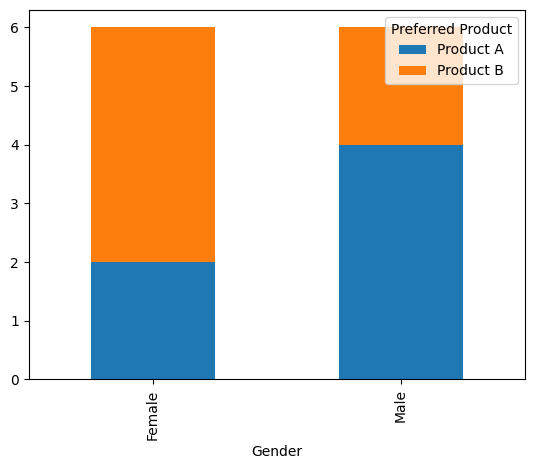

In [8]:
#exercicio 3
import pandas as pd
import matplotlib.pyplot as plt

#carregar a base de dados
df_produtos = pd.read_csv("product.csv")

#o crostab cruza as tabelas e cria uma tabela de contingencia
valores_observados = pd.crosstab(df_produtos['Gender'],df_produtos['Preferred Product'])

#criar um grafico de barras

fig_contingencia = valores_observados.plot(kind='bar', stacked=True)
plt.show()

